In [6]:

import pandas as pd
import matplotlib.pyplot as plt

# Load QB data

df = "https://raw.githubusercontent.com/6ikh/NCAATransfers/main/data/transfers_2021_2025_adj.xlsx"
df = pd.read_excel(df, sheet_name="QB")

# Basic summary of QB data
print("Number of QB season records:", len(df))
print("Number of unique QBs:", df["id"].nunique())

print("\nSeasons:")
print(df["season"].value_counts().sort_index())

print("\nTransfer directions:")
print(df["transfer_direction"].value_counts())

print("\nQB statistics summary:")
print(df[[
    "adjPPA",
    "avgPPA_pass",
    "avgPPA_all",
    "passing_ATT",
    "usage_overall"
]].describe())

Number of QB season records: 1033
Number of unique QBs: 386

Seasons:
season
2021    183
2022    218
2023    253
2024    215
2025    164
Name: count, dtype: int64

Transfer directions:
transfer_direction
P->P      112
NP->NP     99
P->NP      92
NP->P      70
Name: count, dtype: int64

QB statistics summary:
            adjPPA  avgPPA_pass   avgPPA_all  passing_ATT  usage_overall
count  1020.000000   989.000000  1020.000000   993.000000    1020.000000
mean      0.282572     0.194956     0.216529   146.386707       0.308625
std       0.049835     0.477455     0.427451   147.691502       0.206033
min       0.125898    -2.148000    -2.188000     1.000000       0.011000
25%       0.254602     0.052000     0.086000    17.000000       0.101000
50%       0.282125     0.221000     0.233500    84.000000       0.326000
75%       0.301318     0.359000     0.352000   269.000000       0.492250
max       0.540535     6.900000     6.900000   610.000000       0.886000


In [7]:
# Keep only transfer-in seasons
transfer_qbs = df[df["transfer_in"] == "Y"].copy()

# Exclude QBs whose previous conference was non-FBS
transfer_qbs = transfer_qbs[
    transfer_qbs["prev_conference"] != "non-FBS"
].copy()

# Statistics from all QB seasons that can serve as the previous season
previous_seasons = df[[
    "id",
    "season",
    "team",
    "adjPPA",
    "avgPPA_pass",
    "avgPPA_all",
    "passing_ATT",
    "usage_overall"
]].copy()

# Match each transfer-in season to that QB's previous season
qb_comparison = transfer_qbs.merge(
    previous_seasons,
    left_on=["id", "prev_season"],
    right_on=["id", "season"],
    how="left",
    suffixes=("_transfer", "_previous")
)

In [4]:
# Select columns for comparing previous and transfer seasons
qb_comparison = qb_comparison[[
    "id",
    "name",
    "season_previous",
    "team_previous",
    "season_transfer",
    "team_transfer",
    "adjPPA_previous",
    "adjPPA_transfer",
    "avgPPA_pass_previous",
    "avgPPA_pass_transfer",
    "avgPPA_all_previous",
    "avgPPA_all_transfer",
    "passing_ATT_previous",
    "passing_ATT_transfer",
    "usage_overall_previous",
    "usage_overall_transfer"
]]

# Display matched quarterbacks
print(qb_comparison)

          id             name  season_previous       team_previous  \
0    4363148         AJ Mayer             2021          Miami (OH)   
1    5081405         AJ Swann             2023          Vanderbilt   
2    5081405         AJ Swann             2024                 LSU   
3    4361182  Adrian Martinez             2021            Nebraska   
4    5075805     Aidan Chiles             2023        Oregon State   
..       ...              ...              ...                 ...   
313  4568336      Zach Gibson             2024       Georgia State   
314  4808719      Zach Wilcke             2022       Southern Miss   
315  4870518      Zeon Chriss             2023           Louisiana   
316  4685697      Zion Turner             2023               UConn   
317  4685697      Zion Turner             2024  Jacksonville State   

     season_transfer       team_transfer  adjPPA_previous  adjPPA_transfer  \
0               2022      Arkansas State         0.299004         0.270941   
1  

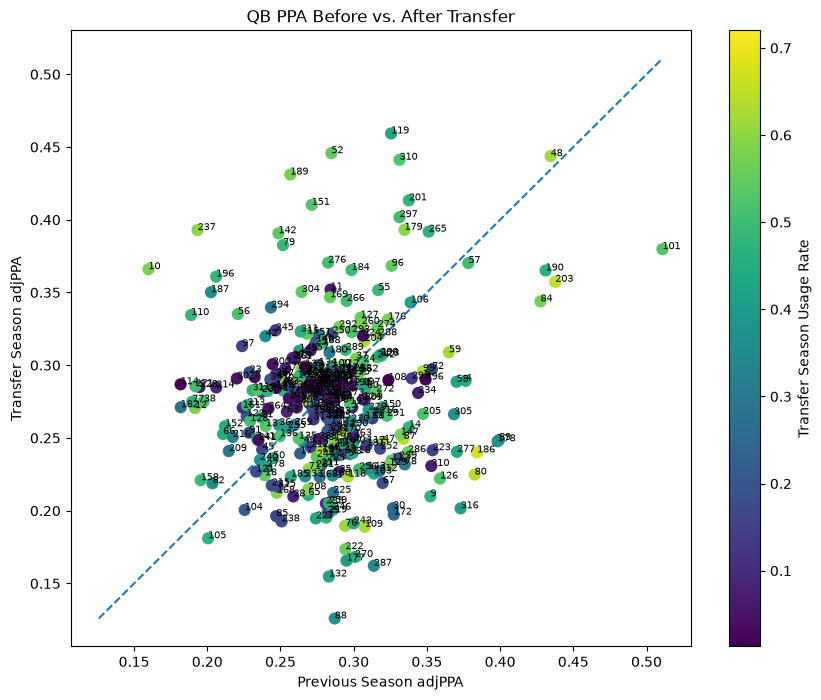

In [9]:
# Pre-transfer and transfer-season PPA
x = qb_comparison["adjPPA_previous"]
y = qb_comparison["adjPPA_transfer"]

plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    x,
    y,
    c=qb_comparison["usage_overall_transfer"],
    s=60
)

# Add a number to each dot
for i in range(len(qb_comparison)):
    plt.text(
        x.iloc[i],
        y.iloc[i],
        str(i + 1),
        fontsize=7
    )

# 1:1 reference line
low = min(x.min(), y.min())
high = max(x.max(), y.max())

plt.plot([low, high], [low, high], "--")

# Labels
plt.xlabel("Previous Season adjPPA")
plt.ylabel("Transfer Season adjPPA")
plt.title("QB PPA Before vs. After Transfer")

plt.colorbar(scatter, label="Transfer Season Usage Rate")

plt.show()

In [10]:
# Create QB number for the table
qb_comparison["number"] = range(1, len(qb_comparison) + 1)

# Table matching each number to a QB
qb_table = qb_comparison[[
    "number",
    "name",
    "season_previous",
    "team_previous",
    "season_transfer",
    "team_transfer",
    "adjPPA_previous",
    "adjPPA_transfer"
]]

print(qb_table.to_string(index=False))

 number                  name  season_previous         team_previous  season_transfer         team_transfer  adjPPA_previous  adjPPA_transfer
      1              AJ Mayer             2021            Miami (OH)             2022        Arkansas State         0.299004         0.270941
      2              AJ Swann             2023            Vanderbilt             2024                   LSU         0.275037         0.281196
      3              AJ Swann             2024                   LSU             2025             App State         0.281196         0.195212
      4       Adrian Martinez             2021              Nebraska             2022          Kansas State         0.376407         0.289278
      5          Aidan Chiles             2023          Oregon State             2024        Michigan State         0.348599         0.292371
      6           Alan Bowman             2022              Michigan             2023        Oklahoma State         0.308546         0.286860
      

In [11]:
# Calculate the change in adjPPA
qb_comparison["adjPPA_change"] = (
    qb_comparison["adjPPA_transfer"]
    - qb_comparison["adjPPA_previous"]
)

# Sort from biggest improvement to biggest decline
qb_comparison = qb_comparison.sort_values(
    "adjPPA_change",
    ascending=False
).reset_index(drop=True)

# Keep only the top 50
top_50 = qb_comparison.head(50).copy()

# Give them ranks 1-50
top_50["rank"] = range(1, 51)

# Create table
qb_table = top_50[[
    "rank",
    "name",
    "season_previous",
    "team_previous",
    "season_transfer",
    "team_transfer",
    "adjPPA_previous",
    "adjPPA_transfer",
    "adjPPA_change"
]]

print(qb_table.to_string(index=False))

 rank               name  season_previous     team_previous  season_transfer     team_transfer  adjPPA_previous  adjPPA_transfer  adjPPA_change
    1  Anthony Colandrea             2024          Virginia             2025              UNLV         0.159753         0.366020       0.206266
    2  Michael Penix Jr.             2021           Indiana             2022        Washington         0.193343         0.392884       0.199541
    3     Jordan McCloud             2021           Arizona             2023     James Madison         0.256693         0.431076       0.174383
    4       Cameron Ward             2023  Washington State             2024             Miami         0.284722         0.445767       0.161045
    5       Katin Houser             2023    Michigan State             2024     East Carolina         0.206059         0.360920       0.154861
    6       John Paddock             2022        Ball State             2023          Illinois         0.202467         0.350212       0